In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from pytorch_msssim import ssim # pip install pytorch-msssim
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator
import matplotlib.pyplot as plt
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 1. Dataset
class LetterDataset(Dataset):
    def __init__(self, size, seed):
        self.gen = LowerCaseLettersGenerator(seed=seed)
        self.size = size
    def __len__(self): return self.size
    def __getitem__(self, idx):
        img, _ = self.gen.generate()
        return torch.tensor(img/255.0, dtype=torch.float32).unsqueeze(0)

train_loader = DataLoader(LetterDataset(60000, 42), batch_size=256, shuffle=True)
val_loader = DataLoader(LetterDataset(15000, 999), batch_size=256, shuffle=False)

# --- Модель ---
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(), # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(), # 7x7
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 64 * 7 * 7), nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
    def forward(self, x): return self.decoder(self.encoder(x))


# 2. Комбинированный Loss
class CustomLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        # Комбинируем L1 (резкость) и SSIM (структура)
        # SSIM возвращает значение от 0 до 1, нам нужно минимизировать (1 - ssim)
        ssim_val = 1 - ssim(pred, target, data_range=1.0, size_average=True)
        l1_val = self.l1(pred, target)
        return l1_val + ssim_val

# 3. Обучение с валидацией
def train_and_validate(model, train_loader, val_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = CustomLoss()

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for data in train_loader:
            img = data.to(DEVICE)
            output = model(img)
            loss = criterion(output, img)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_loader:
                img = data.to(DEVICE)
                output = model(img)
                val_loss += criterion(output, img).item()

        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.5f} | Val Loss: {val_loss/len(val_loader):.5f}")


model = Autoencoder().to(DEVICE)
train_and_validate(model, train_loader, val_loader)

Epoch 1 | Train Loss: 0.70262 | Val Loss: 0.18131
Epoch 2 | Train Loss: 0.10378 | Val Loss: 0.06403
Epoch 3 | Train Loss: 0.04876 | Val Loss: 0.03821
Epoch 4 | Train Loss: 0.03309 | Val Loss: 0.02916
Epoch 5 | Train Loss: 0.02440 | Val Loss: 0.02195


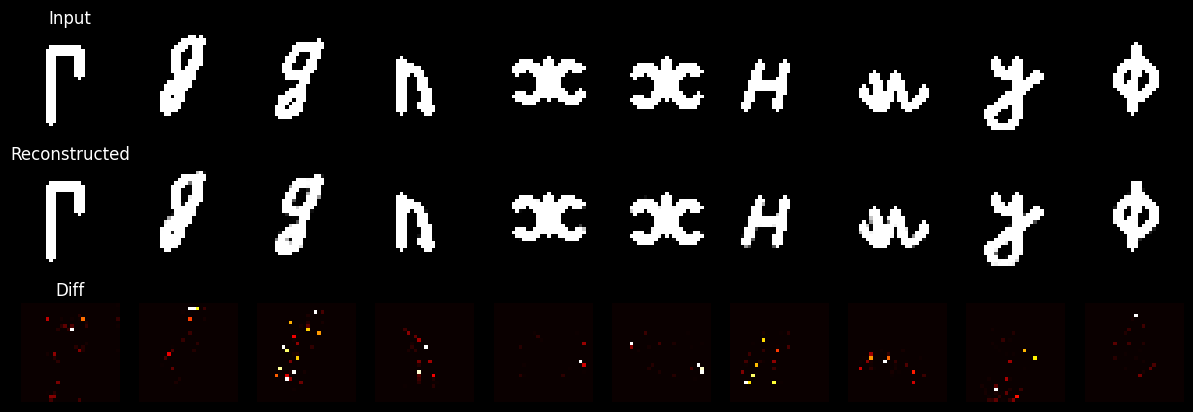

In [10]:
def visualize_results(model, loader, num_images=10):
    model.eval()
    data = next(iter(loader))
    with torch.no_grad():
        imgs = data[:num_images].to(DEVICE)
        outputs = model(imgs)

    fig, axes = plt.subplots(3, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[1, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
        axes[2, i].imshow(torch.abs(imgs[i] - outputs[i]).cpu().squeeze(), cmap='hot')
        for ax in axes[:, i]: ax.axis('off')
    axes[0, 0].set_title("Input")
    axes[1, 0].set_title("Reconstructed")
    axes[2, 0].set_title("Diff")
    plt.show()

visualize_results(model, val_loader)

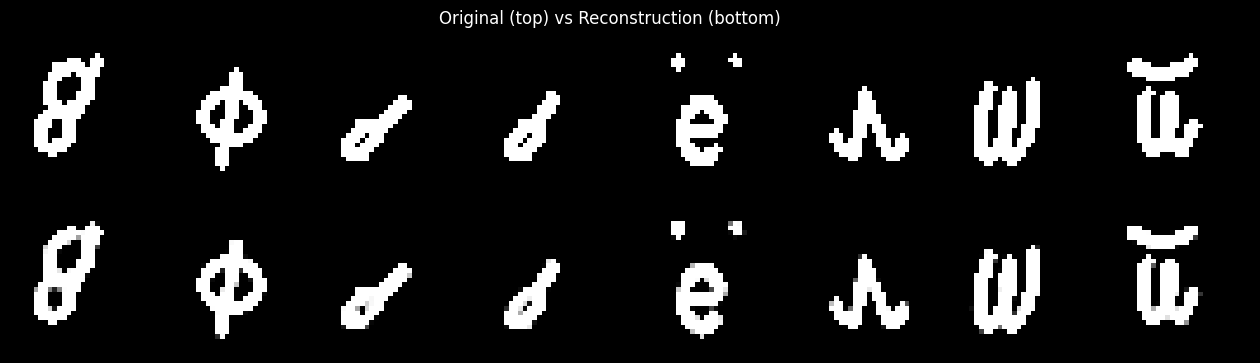

In [9]:
def show_collage(model, loader):
    model.eval()
    data = next(iter(loader))
    with torch.no_grad():
        imgs = data[:8].to(DEVICE)
        outputs = model(imgs)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[1, i].imshow(outputs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off'); axes[1, i].axis('off')
    plt.suptitle("Original (top) vs Reconstruction (bottom)")
    plt.show()

show_collage(model, val_loader)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Архитектура cAE
class ConditionalAE(nn.Module):
    def __init__(self, cond_dim=1):
        super().__init__()
        # Латентный код = 32
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(), # 14x14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(), # 7x7
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 32)
        )
        # Декодер принимает (латентный код + cond_dim)
        self.decoder = nn.Sequential(
            nn.Linear(32 + cond_dim, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
        self.cond_dim = cond_dim

    def forward(self, x, cond):
        z = self.encoder(x)
        z = torch.cat([z, cond], dim=1) # "Сшиваем" латентный код с условием
        return self.decoder(z)

# 2. Инициализация
model = ConditionalAE(cond_dim=1).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# 3. Цикл обучения с условием
def train_cAE(model, loader, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data in loader:
            imgs = data.to(DEVICE)

            # Генерируем "псевдо-наклон" для обучения.
            # В реальности тут должен быть ваш вычисленный параметр буквы.
            # Пока учим модель связывать [0, 1] с "типом" буквы или её параметром.
            cond = torch.rand(imgs.size(0), 1).to(DEVICE)

            output = model(imgs, cond)
            loss = criterion(output, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.5f}")

train_cAE(model, train_loader)

Epoch 1 | Loss: 0.04717
Epoch 2 | Loss: 0.01150
Epoch 3 | Loss: 0.00806
Epoch 4 | Loss: 0.00655
Epoch 5 | Loss: 0.00569


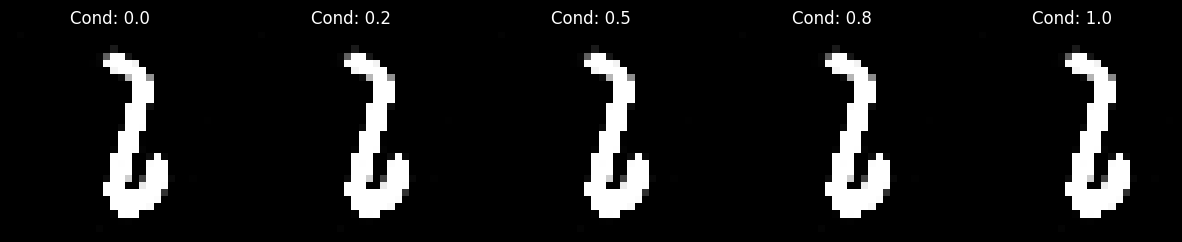

In [20]:
def generate_variations(model, img, steps=5):
    model.eval()
    img = img.to(DEVICE).unsqueeze(0)

    # Создаем ряд условий от 0 до 1
    conditions = torch.linspace(0, 1, steps).unsqueeze(1).to(DEVICE)

    fig, axes = plt.subplots(1, steps, figsize=(15, 3))
    with torch.no_grad():
        for i in range(steps):
            recon = model(img, conditions[i:i+1])
            axes[i].imshow(recon.cpu().squeeze(), cmap='gray')
            axes[i].set_title(f"Cond: {conditions[i].item():.1f}")
            axes[i].axis('off')
    plt.show()

# Пример: берем любую букву и смотрим, как она меняется
generate_variations(model, next(iter(val_loader))[0])

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from pytorch_msssim import ssim
import numpy as np
from mnist_synthetic.lower_case_letters_generator_for_ae import LowerCaseLettersGeneratorForAE
import matplotlib.pyplot as plt
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 1. Dataset с поддержкой параметров
class ConditionalLetterDataset(Dataset):
    def __init__(self, size, seed):
        self.gen = LowerCaseLettersGeneratorForAE(seed=seed)
        self.size = size
    def __len__(self): return self.size
    def __getitem__(self, idx):
        # Генерируем картинку, лейбл (игнорируем) и вектор параметров
        img, _, params = self.gen.generate_with_params()
        # img: (1, 28, 28), params: (N,)
        return torch.tensor(img/255.0, dtype=torch.float32).unsqueeze(0), torch.tensor(params, dtype=torch.float32)

# Параметры: у нас 3 параметра (наклон, ширина, высота/наклон ножек)
COND_DIM = 3
train_loader = DataLoader(ConditionalLetterDataset(60000, 42), batch_size=256, shuffle=True)
val_loader = DataLoader(ConditionalLetterDataset(15000, 999), batch_size=256, shuffle=False)

# 2. Модель CAE
class ConditionalAE(nn.Module):
    def __init__(self, cond_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 32), # Уменьшили до 32 (было 128)
            nn.Dropout(0.2)           # Добавили регуляризацию
        )
        self.decoder = nn.Sequential(
            nn.Linear(32 + cond_dim, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
    def forward(self, x, cond):
        z = self.encoder(x)
        # Усиливаем влияние условий: умножаем cond на коэффициент,
        # чтобы они были сопоставимы по масштабу с z
        return self.decoder(torch.cat([z, cond * 2.0], dim=1))

# 3. Лосс и Обучение
class CustomLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss() # Бинарная кросс-энтропия
    def forward(self, pred, target):
        ssim_val = 1 - ssim(pred, target, data_range=1.0)
        return self.bce(pred, target) + ssim_val

model = ConditionalAE(cond_dim=COND_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = CustomLoss()

def train_and_validate_cae(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, conds in train_loader:
            imgs, conds = imgs.to(DEVICE), conds.to(DEVICE)
            output = model(imgs, conds)
            loss = criterion(output, imgs)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, conds in val_loader:
                imgs, conds = imgs.to(DEVICE), conds.to(DEVICE)
                output = model(imgs, conds)
                val_loss += criterion(output, imgs).item()

        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.5f} | Val Loss: {val_loss/len(val_loader):.5f}")

train_and_validate_cae(model, train_loader, val_loader)

Epoch 1 | Train Loss: 0.29749 | Val Loss: 0.02057
Epoch 2 | Train Loss: 0.02345 | Val Loss: 0.00487
Epoch 3 | Train Loss: 0.00901 | Val Loss: 0.00216
Epoch 4 | Train Loss: 0.00497 | Val Loss: 0.00128
Epoch 5 | Train Loss: 0.00326 | Val Loss: 0.00079


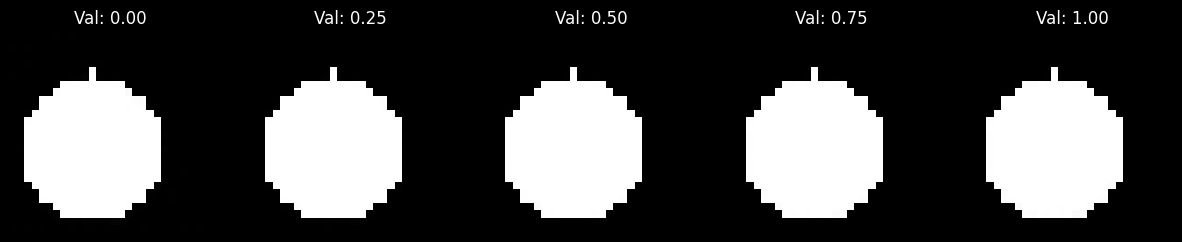

In [7]:
def test_determinism(model):
    model.eval()
    # Возьмем одну картинку
    img, _ = val_loader.dataset[0]
    img = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        z = model.encoder(img) # Получаем "суть" буквы

        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        for i, val in enumerate(np.linspace(0, 1, 5)):
            cond = torch.tensor([[val, 0.5, 0.5]], dtype=torch.float32).to(DEVICE)
            output = model.decoder(torch.cat([z, cond * 2.0], dim=1))

            axes[i].imshow(output.cpu().squeeze(), cmap='gray')
            axes[i].set_title(f"Val: {val:.2f}")
            axes[i].axis('off')
        plt.show()

test_determinism(model)

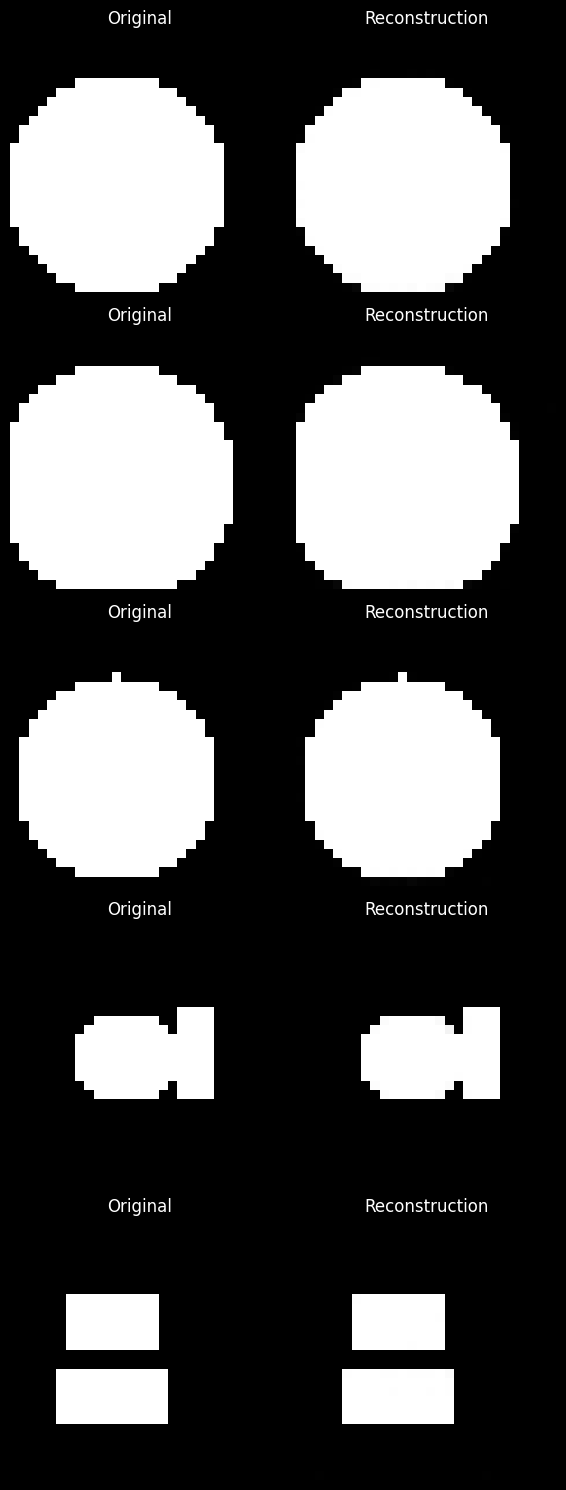

In [8]:
def visualize_dataset_samples(model, loader, num_samples=5):
    model.eval()
    data_iter = iter(loader)
    imgs, conds = next(data_iter)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 3 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img = imgs[i:i+1].to(DEVICE)
            cond = conds[i:i+1].to(DEVICE)
            output = model(img, cond)

            axes[i, 0].imshow(img.cpu().squeeze(), cmap='gray')
            axes[i, 0].set_title("Original")
            axes[i, 1].imshow(output.cpu().squeeze(), cmap='gray')
            axes[i, 1].set_title("Reconstruction")
            axes[i, 0].axis('off'); axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_dataset_samples(model, val_loader)

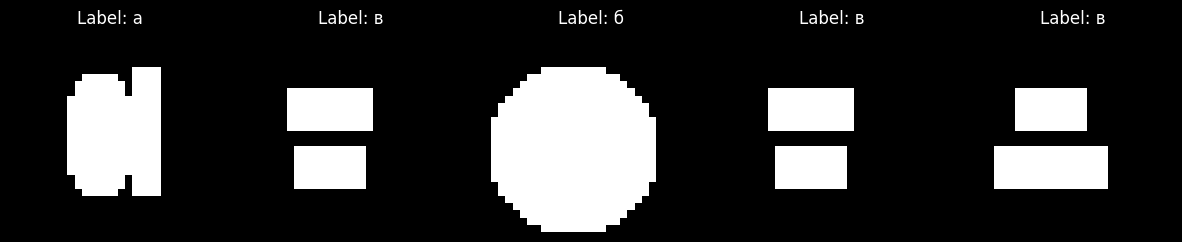

In [9]:
# --- ПРОВЕРКА ГЕНЕРАТОРА (БЕЗ НЕЙРОСЕТИ) ---
gen = LowerCaseLettersGeneratorForAE(seed=42)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label, params = gen.generate_with_params()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.show()